In [1]:
pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.6 MB/s eta 0:00:00


Final Objective Values:
[[-4976.86885586   175.47218393]
 [-5626.8437937    420.51995185]
 [-5623.00665189   352.99161451]
 ...
 [-5626.70061486   418.39217469]
 [-5471.6193597    233.72487198]
 [-5243.01448283   197.24185379]]

Final Decision Variables:
[[2.5        2.5        2.50000002 ... 2.5        2.5        2.69899961]
 [2.5        2.54099977 2.7589997  ... 2.50000001 2.69899602 2.50000006]
 [2.5        2.54099974 2.75899962 ... 2.50000001 2.50717311 2.50000035]
 ...
 [2.5        2.54099974 2.75899959 ... 2.5        2.69233801 2.5000012 ]
 [2.5        2.50000009 2.51500266 ... 2.5        2.50000001 2.69899965]
 [2.5        2.5        2.50000002 ... 2.5        2.5000115  2.69900045]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5583.55187446   288.30921025]
Decision Variables:
[2.5        2.50028593 2.71791743 2.5000003  2.50002137 2.73841895
 2.98441748 2.7314185  2.5        2.50000438 2.69897519]

Worst Solution:
Objective Values (Weig

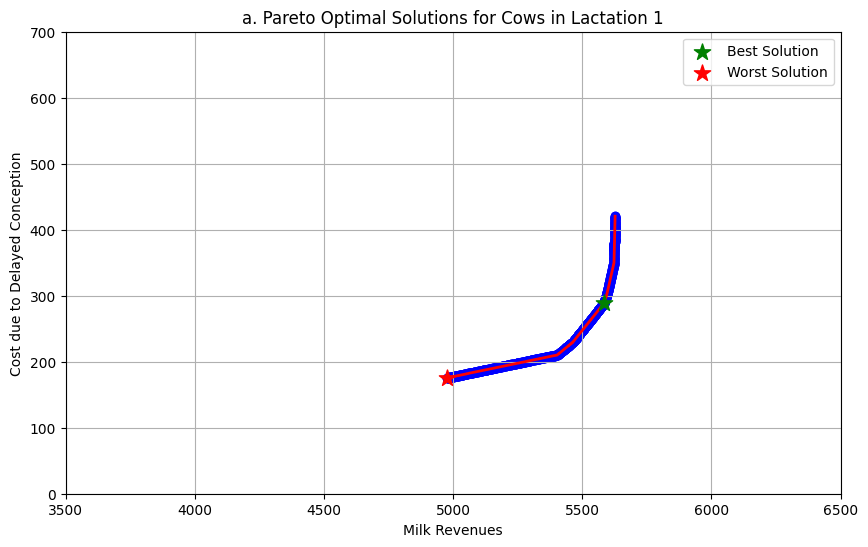

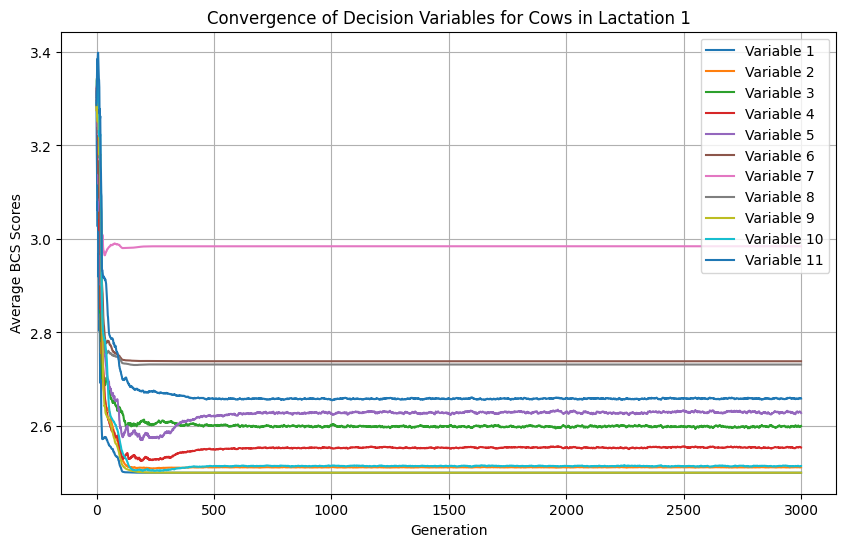

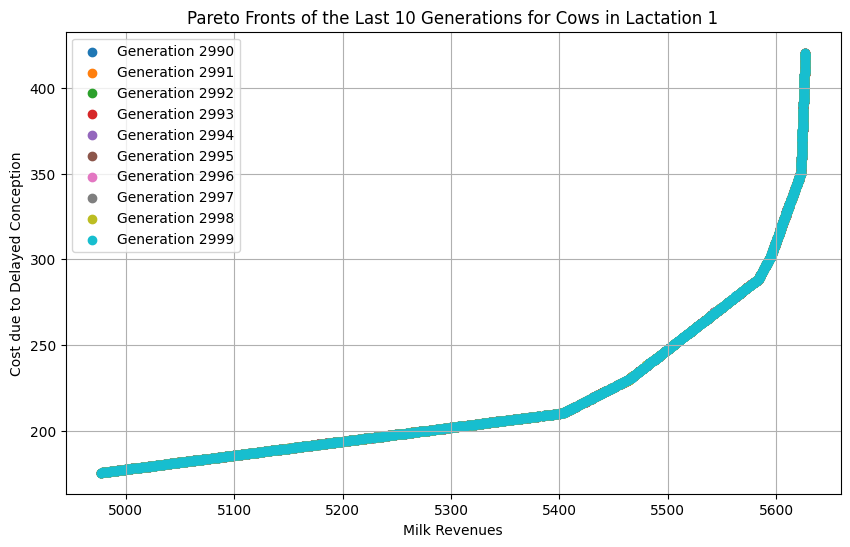

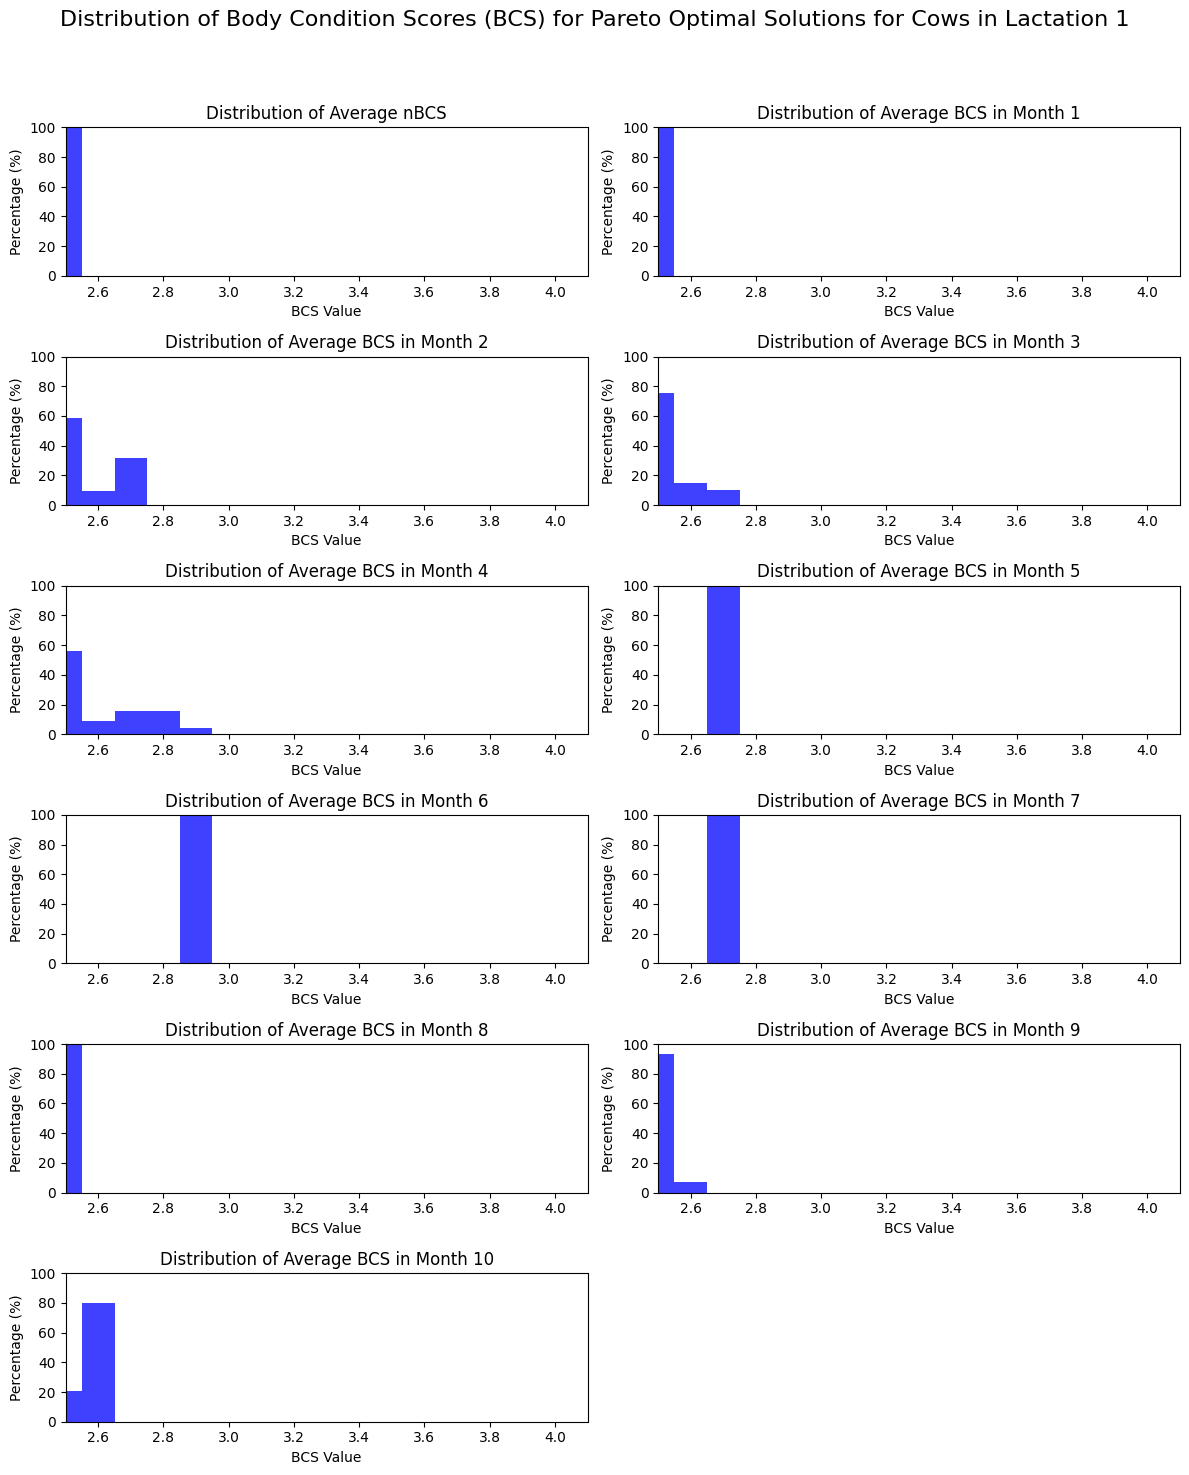

In [2]:
# Lactation1 #both coeff updated
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.218:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.259:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.165:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.259:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.246:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.253:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.233:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.208:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.199:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (23126 - 279 * x[0] - 697 * x[1] + 1368 * x[2]
                               - 3177 * x[3] - 934 * x[4] - 166 * x[5]
                               + 1647 * x[6] - 1341 * x[7] - 54 * x[8]
                               + 50 * x[9] - 354 * x[10])

            conception_DIM = (66.14 - 84.37 * x[0] + 13.26 * x[1] + 56.85 * x[2]
                              - 2.89 * x[3] - 25.40 * x[4] + 28.63 * x[5]
                              - 51.20 * x[6] + 1.21 * x[7] + 56.73 * x[8]
                              + 79.08 * x[9] - 55.42 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])


# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star (plotted after the blue points)
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star (plotted after the blue points)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6500)
plt.ylim(0, 700)

plt.title('a. Pareto Optimal Solutions for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 1')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)  # Create subplots in a 5x2 grid

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage by multiplying by 100
    percentages = counts * np.diff(bins)[0] * 100

    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle(
    'Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 1',
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4762.57893806   305.9994194 ]
 [-5851.50622899   438.48316267]
 [-4857.98378601   308.47507426]
 ...
 [-5466.71082691   341.99790788]
 [-5662.50816041   374.10310785]
 [-5654.43291312   372.35216302]]

Final Decision Variables:
[[2.8527955  2.8528034  2.8528313  ... 2.90906405 2.85279636 2.85280927]
 [2.50000002 2.63419449 2.89419383 ... 2.74993989 2.72085941 2.50000071]
 [2.85278442 2.85278679 2.96436223 ... 2.9090212  2.85280675 2.85278676]
 ...
 [2.5        2.50112236 2.76004101 ... 2.72347619 2.50000121 2.50000157]
 [2.50000002 2.52053915 2.77998625 ... 2.72351999 2.5000127  2.50000007]
 [2.5        2.50103129 2.76095426 ... 2.72173612 2.50000868 2.50000123]]

Best Solution:
Objective Values: [-5851.50622899   438.48316267]
Decision Variables: [2.50000002 2.63419449 2.89419383 2.58683718 2.50571779 2.77571132
 2.52413206 2.50001217 2.74993989 2.72085941 2.50000071]

Worst Solution:
Objective Values: [-4762.57893806   305.9994194 ]
Decision Variables: [2.8

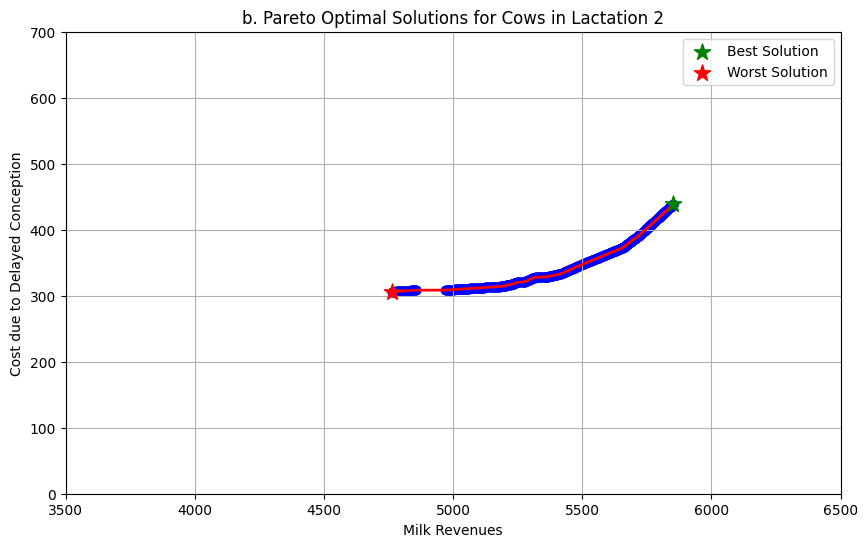

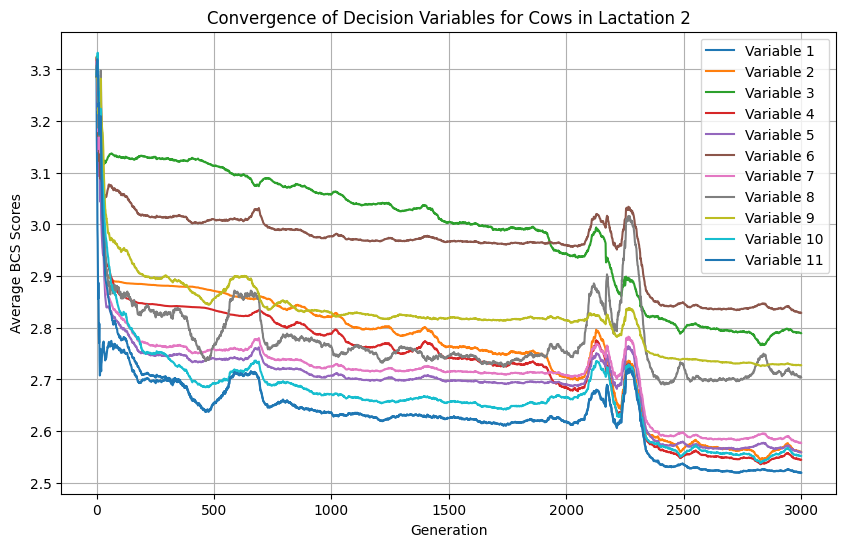

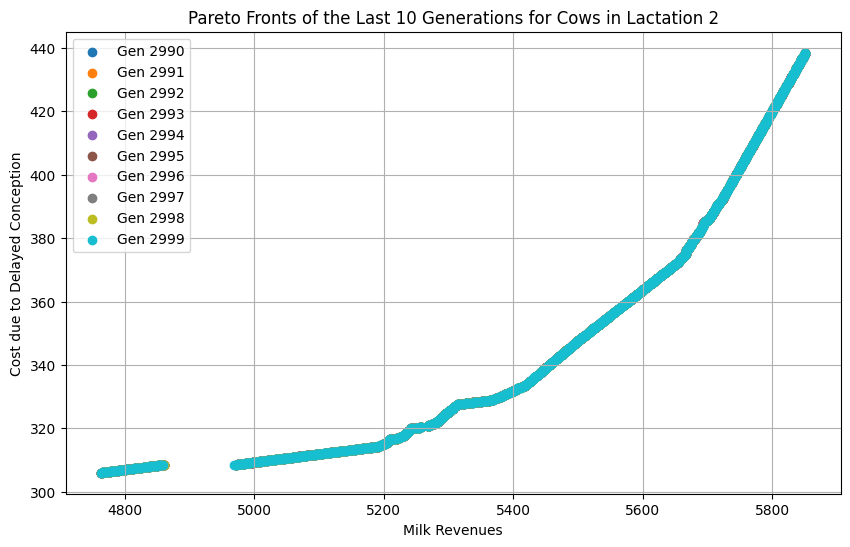

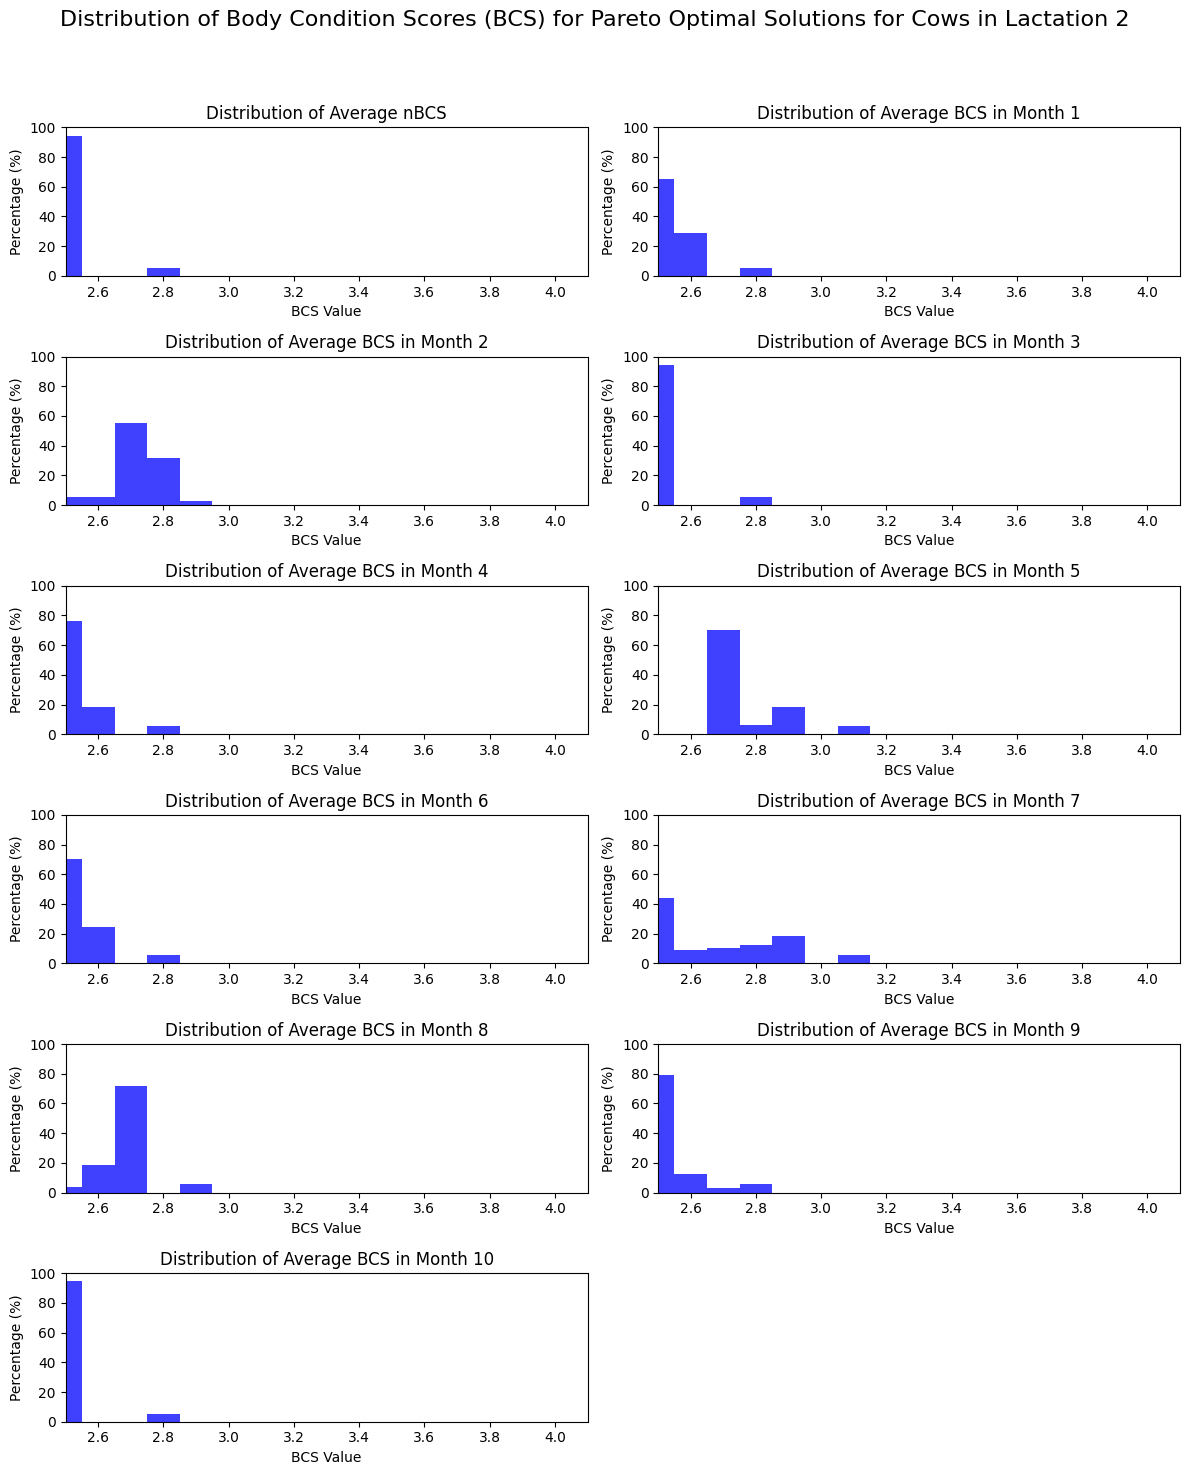

In [3]:
# Lactation 2 ##both coeff updated
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.260:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.308:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.183:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.270:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.252:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.250:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.224:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.221:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20253 - 527 * x[0] - 1254 * x[1] + 2138 * x[2]
                               - 57 * x[3] - 2268 * x[4] + 760 * x[5]
                               - 187 * x[6] - 2015 * x[7] + 380 * x[8]
                               + 1649 * x[9] - 1397 * x[10])

            conception_DIM = (127.94 - 64.52 * x[0] + 12.17 * x[1] + 4.32 * x[2]
                              + 6.62 * x[3] + 2.51 * x[4] - 37.38 * x[5]
                              + 37.99 * x[6] - 27.39 * x[7] + 2.75 * x[8]
                              + 50.08 * x[9] + 2.99 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.40, 4.00, 5.13, 4.73, 4.23, 3.77, 3.27, 2.70, 2.20, 1.67]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(0, 700)
plt.title('b. Pareto Optimal Solutions for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 2')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Gen {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 2', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4620.6508824    223.14985264]
 [-6054.45472177   659.11533981]
 [-4816.72218813   262.46383997]
 ...
 [-5654.69147964   453.04244459]
 [-4864.46561254   274.36080989]
 [-5116.64433603   327.02590525]]

Final Decision Variables:
[[2.87396002 2.87401406 2.87405451 ... 2.87450528 3.13447813 2.87396765]
 [2.50000005 2.56866198 2.87464027 ... 2.7567055  2.76399587 2.50000104]
 [2.69195536 2.69199507 2.69195884 ... 2.69310613 2.95257435 2.6919713 ]
 ...
 [2.50000195 2.50060266 2.50061505 ... 2.50075202 2.76059353 2.50059731]
 [2.69195267 2.69199998 2.69196813 ... 2.69309498 2.95302763 2.69198728]
 [2.50048652 2.50058527 2.50063417 ... 2.50069636 2.7606322  2.50059789]]

Best Solution:
Objective Values: [-6023.48120366   605.71169722]
Decision Variables: [2.50000018 2.56866094 2.87459619 2.5000171  2.50000911 2.79296264
 2.53300143 2.50000534 2.75666733 2.76395585 2.50000106]

Worst Solution:
Objective Values: [-4620.6508824    223.14985264]
Decision Variables: [2.8

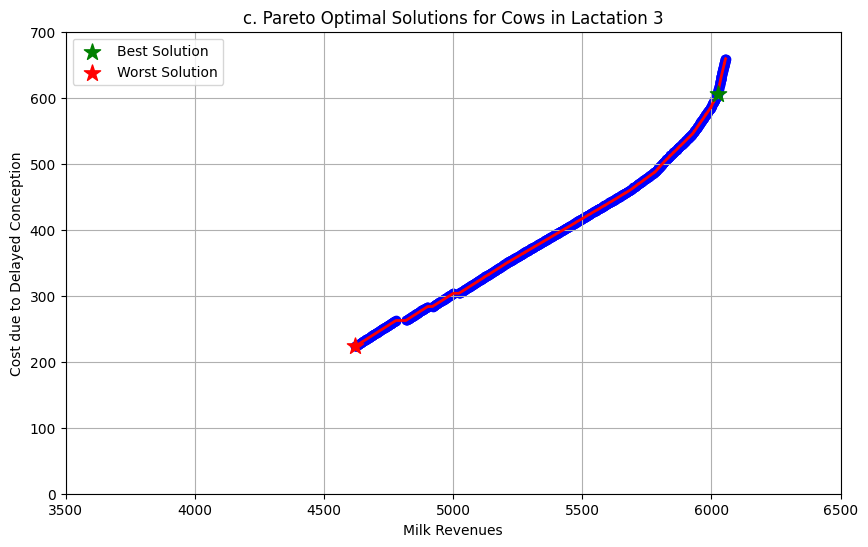

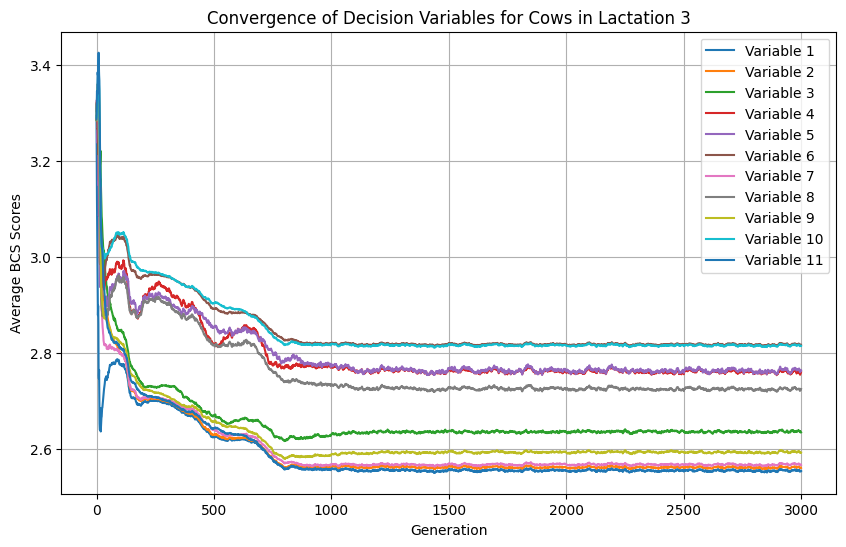

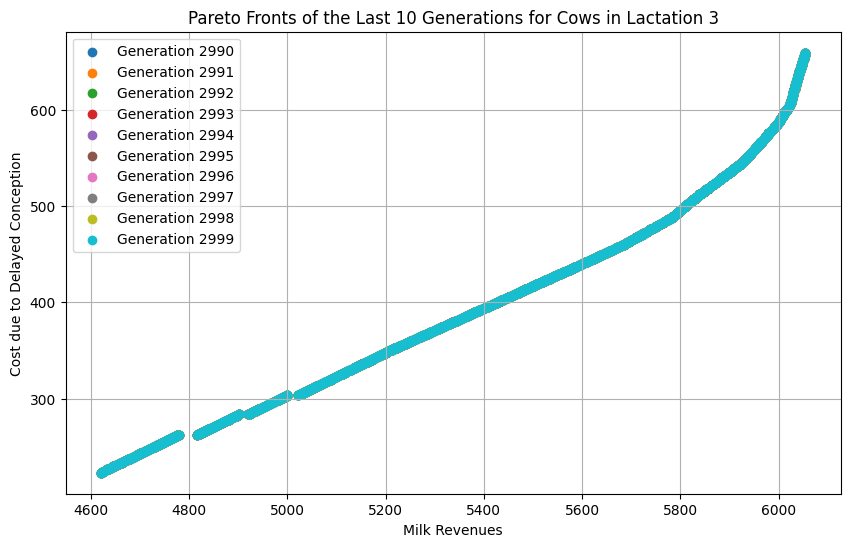

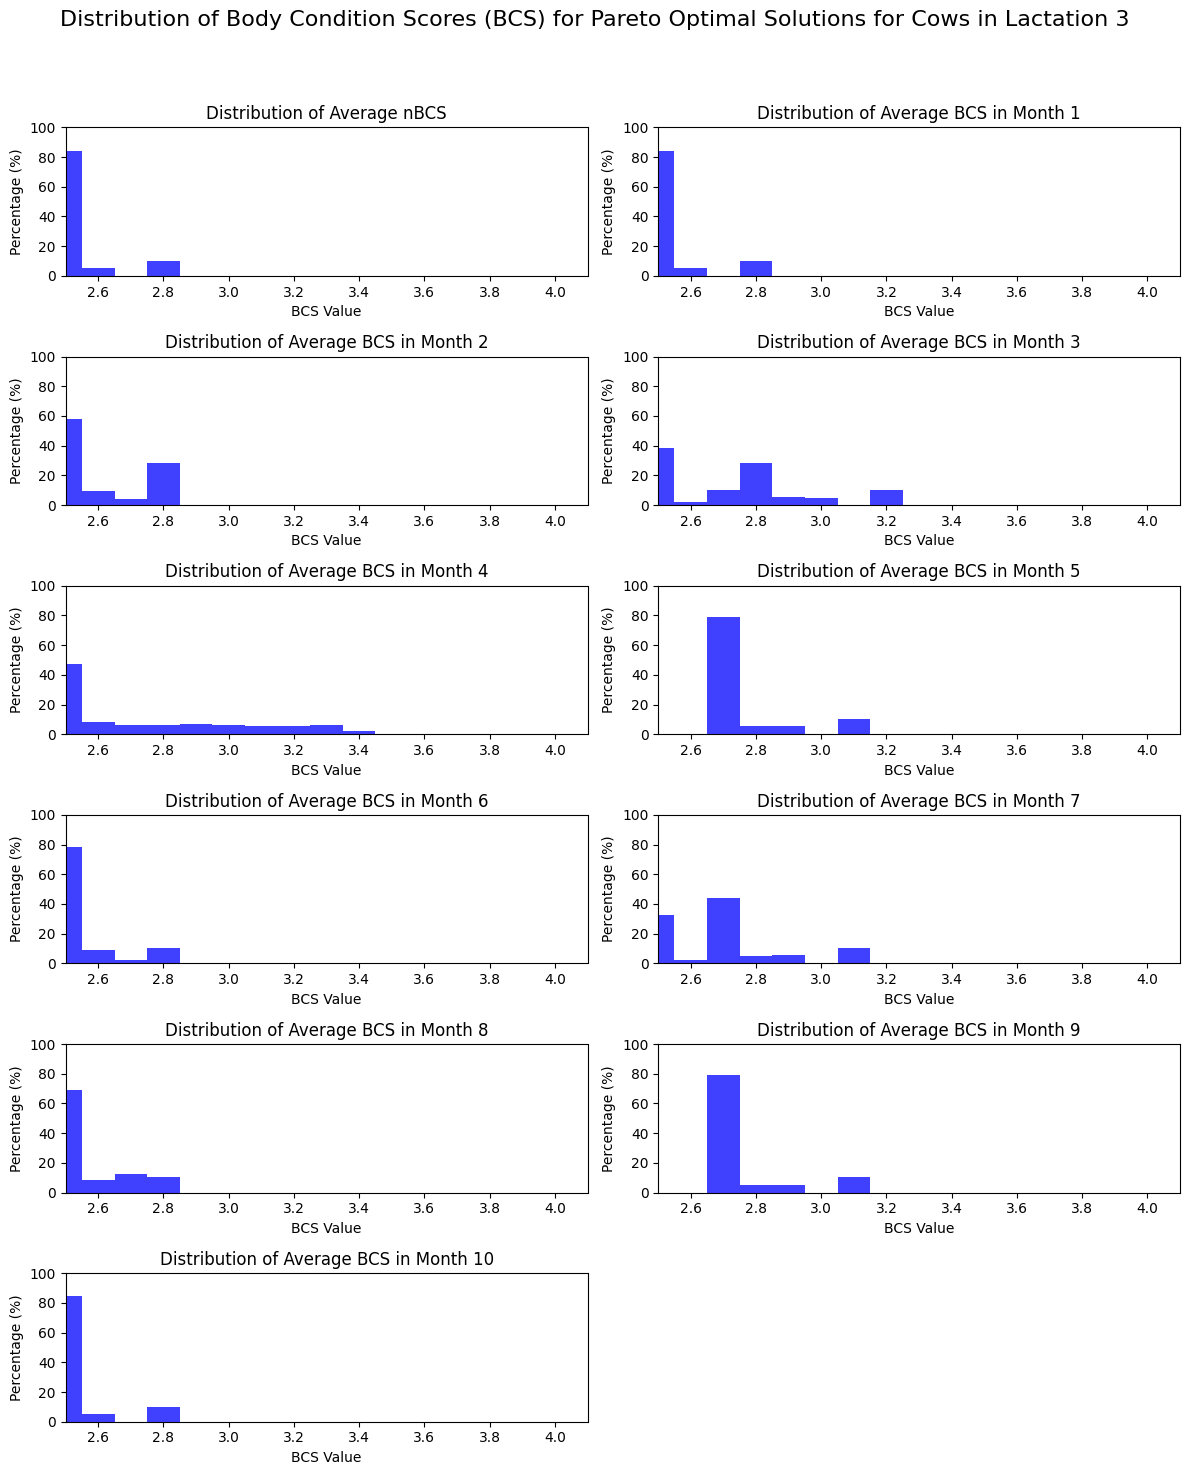

In [4]:
# Lactation 3 ##both
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.306:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.375:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.246:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.293:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.260:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.277:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.260:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.264:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (21109 - 52 * x[0] - 518 * x[1] + 1173 * x[2]
                               - 695 * x[3] - 2526 * x[4] + 180 * x[5]
                               + 317 * x[6] - 932 * x[7] + 712 * x[8]
                               + 123 * x[9] - 475 * x[10])

            conception_DIM = (219.80 - 78.24 * x[0] + 5.27 * x[1] + 40.26 * x[2]
                              - 12.98 * x[3] - 45.43 * x[4] - 12.38 * x[5]
                              + 51.62 * x[6] - 20.82 * x[7] + 35.68 * x[8]
                              - 7.89 * x[9] + 5.90 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.00, 4.13, 5.53, 5.10, 4.50, 3.90, 3.27, 2.60, 1.87, 1.10]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(0, 700)
plt.title('c. Pareto Optimal Solutions for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 3')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 3', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-6026.98457772   708.83007417]
 [-4547.88189896    46.65034663]
 [-5322.73915473   281.87132605]
 ...
 [-5461.66080571   322.91923308]
 [-5918.83517662   556.04140983]
 [-5922.50752585   558.56491113]]

Final Decision Variables:
[[2.50000001 3.43183832 3.15741055 ... 2.84646688 2.99228087 2.76006287]
 [3.15210832 3.15337915 3.42763154 ... 3.15268077 3.38776217 3.15649675]
 [2.69074012 2.977231   3.2526207  ... 2.7081023  2.94315931 2.71027566]
 ...
 [2.50001297 2.71826942 2.99240943 ... 2.50356244 2.73374742 2.50081686]
 [2.50000005 2.88200497 3.15738373 ... 3.0231879  2.77223549 2.54138781]
 [2.50000009 2.88260144 3.15740234 ... 3.03980665 2.7902874  2.55791206]]

Best Solution:
Objective Values: [-5927.66782591   563.41766193]
Decision Variables: [2.50000007 2.88228103 3.15738407 2.779434   2.56047677 2.50000281
 2.50000591 2.75899467 3.05464118 2.8167325  2.58378484]

Worst Solution:
Objective Values: [-4547.88189896    46.65034663]
Decision Variables: [3.1

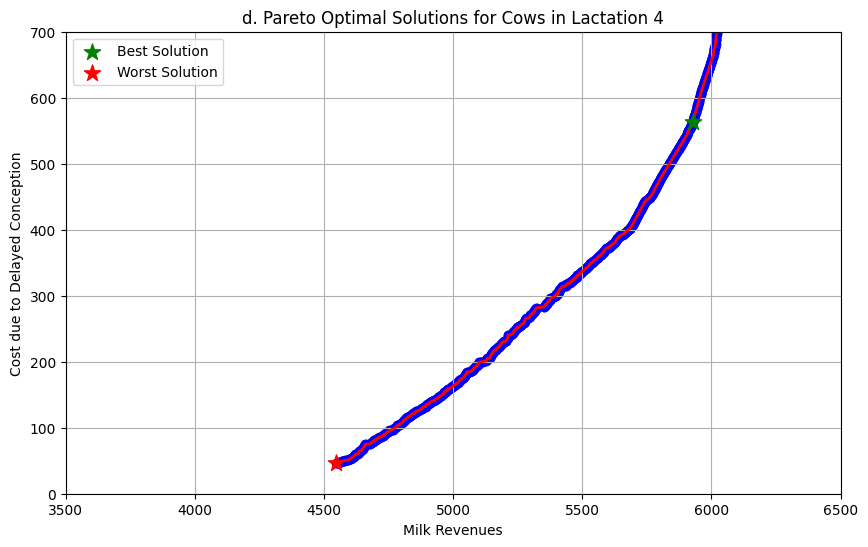

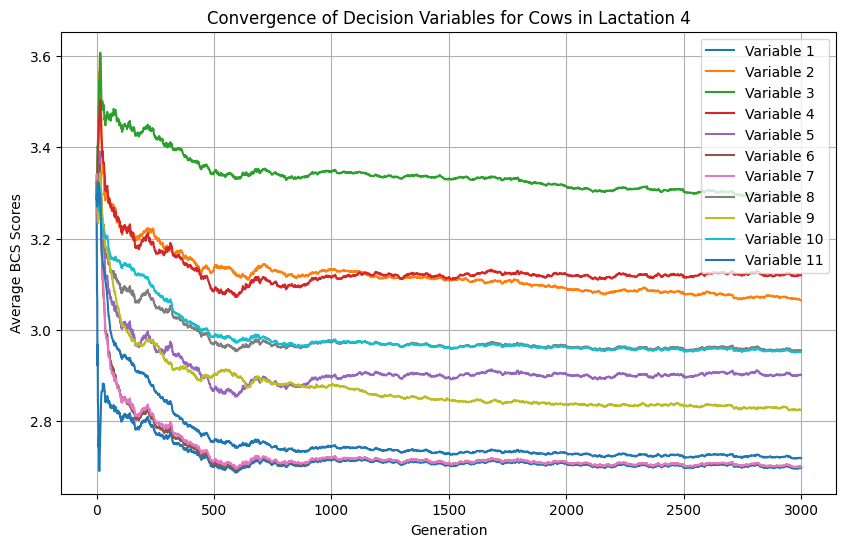

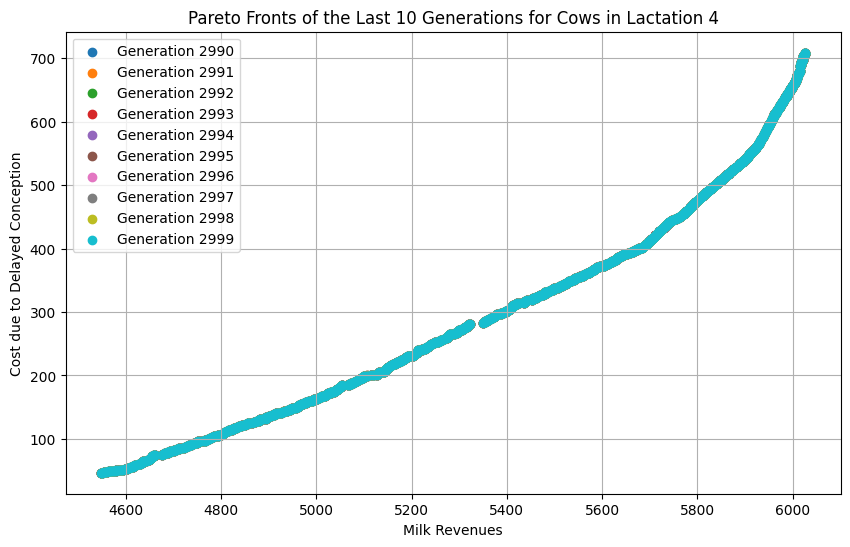

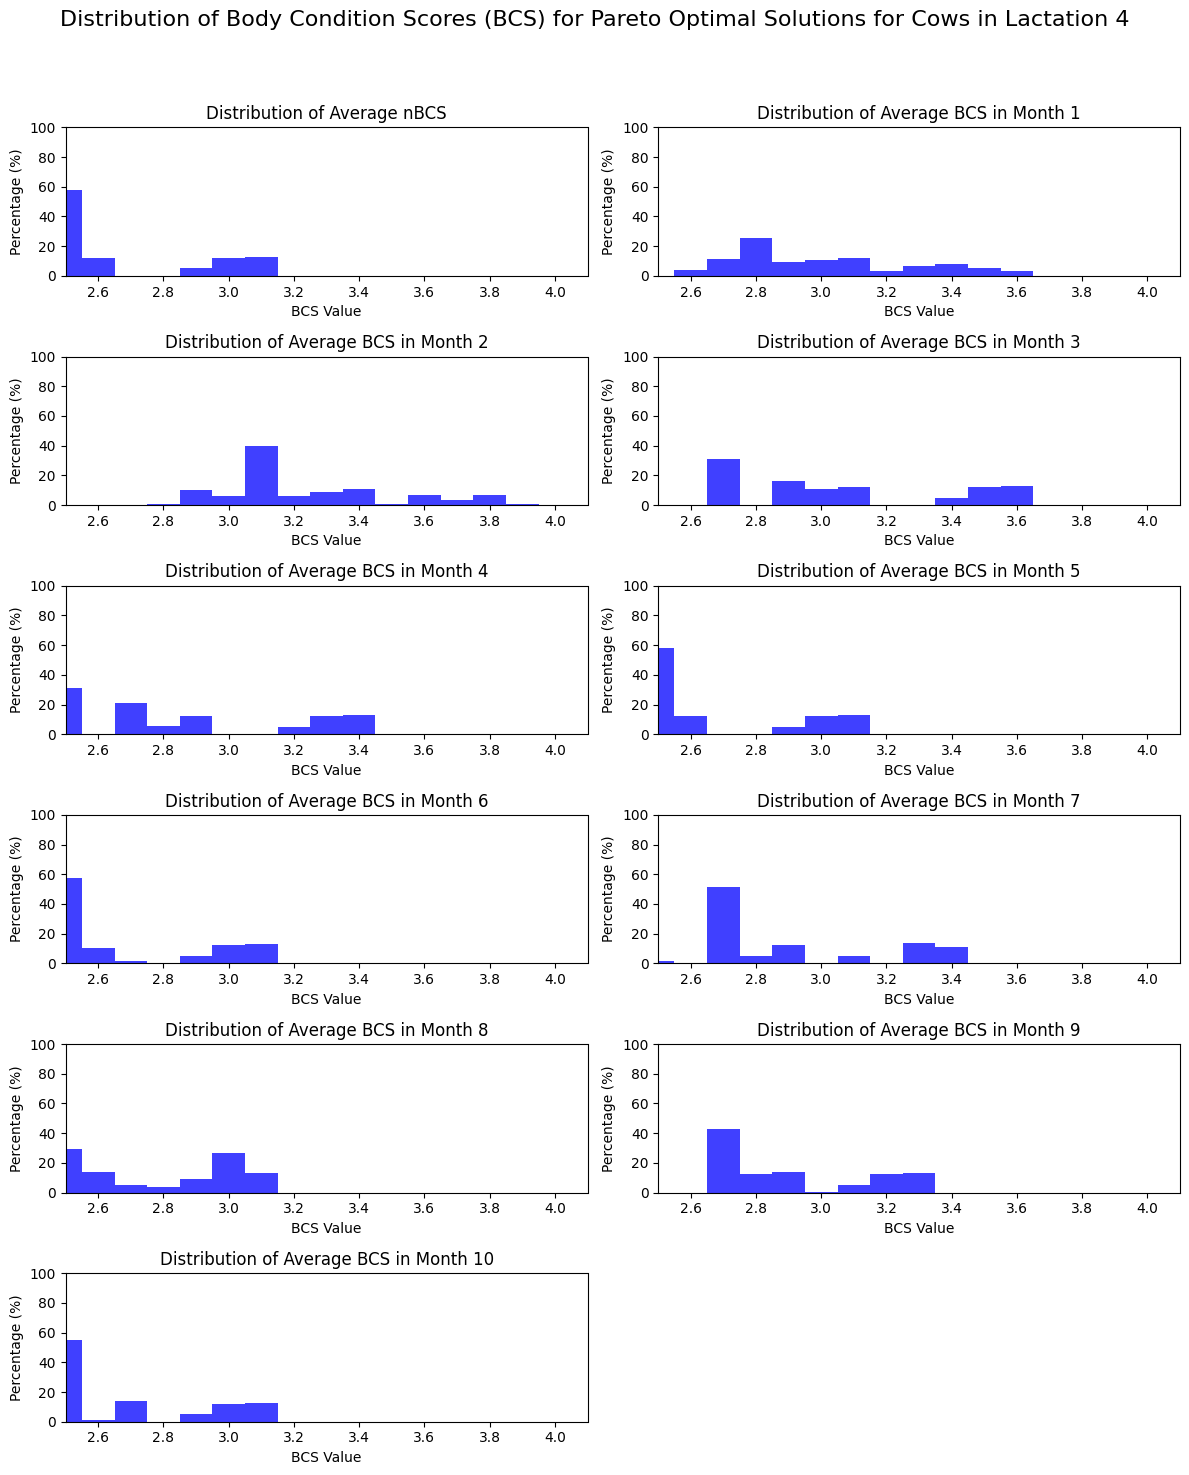

In [5]:
# Lactation 4 # Both
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.276:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.378:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.219:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.271:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.259:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.296:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.251:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.233:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (21028 - 1235 * x[0] + 361 * x[1] + 1036 * x[2]
                               + 913 * x[3] - 3290 * x[4] - 358 * x[5]
                               - 311 * x[6] - 854 * x[7] + 705 * x[8]
                               + 235 * x[9] - 129 * x[10])

            conception_DIM = (341.57 - 99.43 * x[0] + 45.57 * x[1] - 5.64 * x[2]
                              - 69.03 * x[3] - 19.14 * x[4] + 22.69 * x[5]
                              + 63.45 * x[6] - 79.36 * x[7] + 41.36 * x[8]
                              - 11.88 * x[9] + 32.57 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.73, 3.93, 5.37, 4.97, 4.37, 3.80, 3.17, 2.47, 1.77, 0.93]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(0, 700)
plt.title('d. Pareto Optimal Solutions for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 4')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 4', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-5855.36515624   600.30803935]
 [-4061.15814348   251.329478  ]
 [-4778.14701809   318.58706851]
 ...
 [-4435.21743324   282.69810013]
 [-5061.01026254   348.99821966]
 [-4437.8836872    282.74427145]]

Final Decision Variables:
[[2.50000044 2.75095571 3.01692519 ... 3.05317617 3.28132134 3.05547723]
 [3.0751413  3.07567708 3.15800701 ... 3.30773674 3.07578153 3.29693158]
 [2.51417306 2.60512884 2.87053081 ... 3.02287503 2.79296982 2.56934793]
 ...
 [2.81982006 2.82209077 2.87138349 ... 3.02299964 2.82114801 2.82263343]
 [2.50000005 2.50001504 2.59600721 ... 2.53413313 2.50014658 2.50000055]
 [2.80500281 2.80526282 2.87029261 ... 3.02287774 2.80520044 2.86207588]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5853.27727714   591.91507405]
Decision Variables:
[2.50000002 2.75096188 3.01690992 2.69591789 2.50002776 2.77402526
 3.0277023  2.96841018 3.22038871 3.44921216 3.22325911]

Worst Solution:
Objective Values (Weig

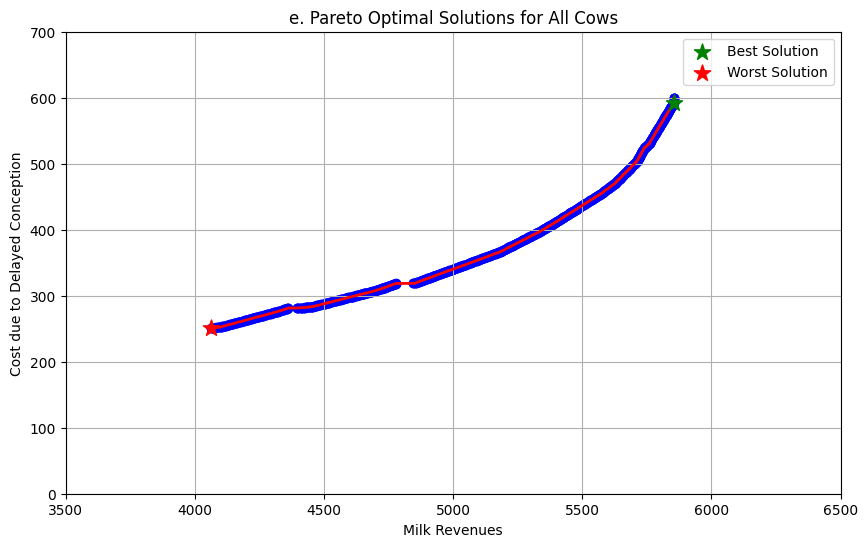

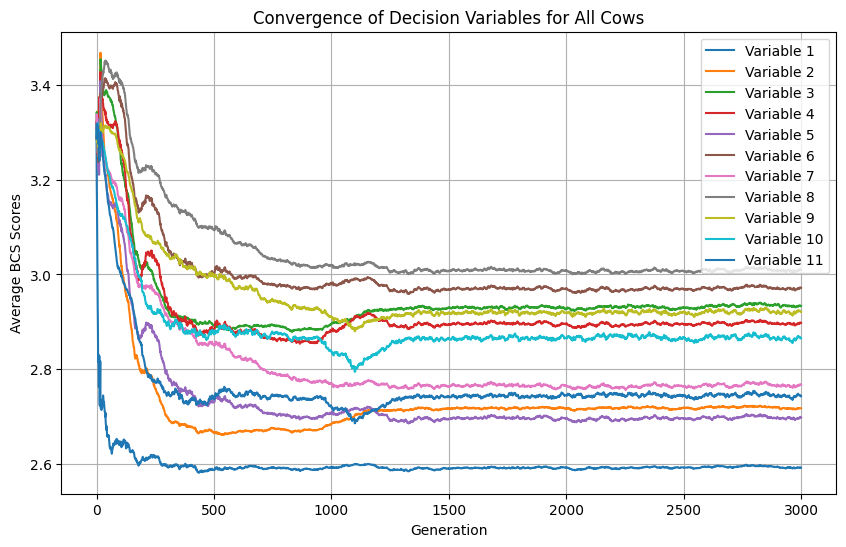

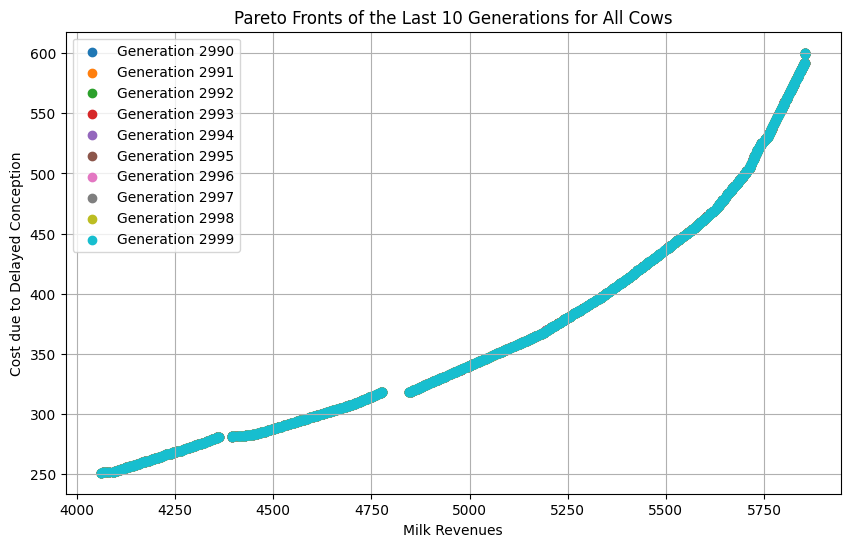

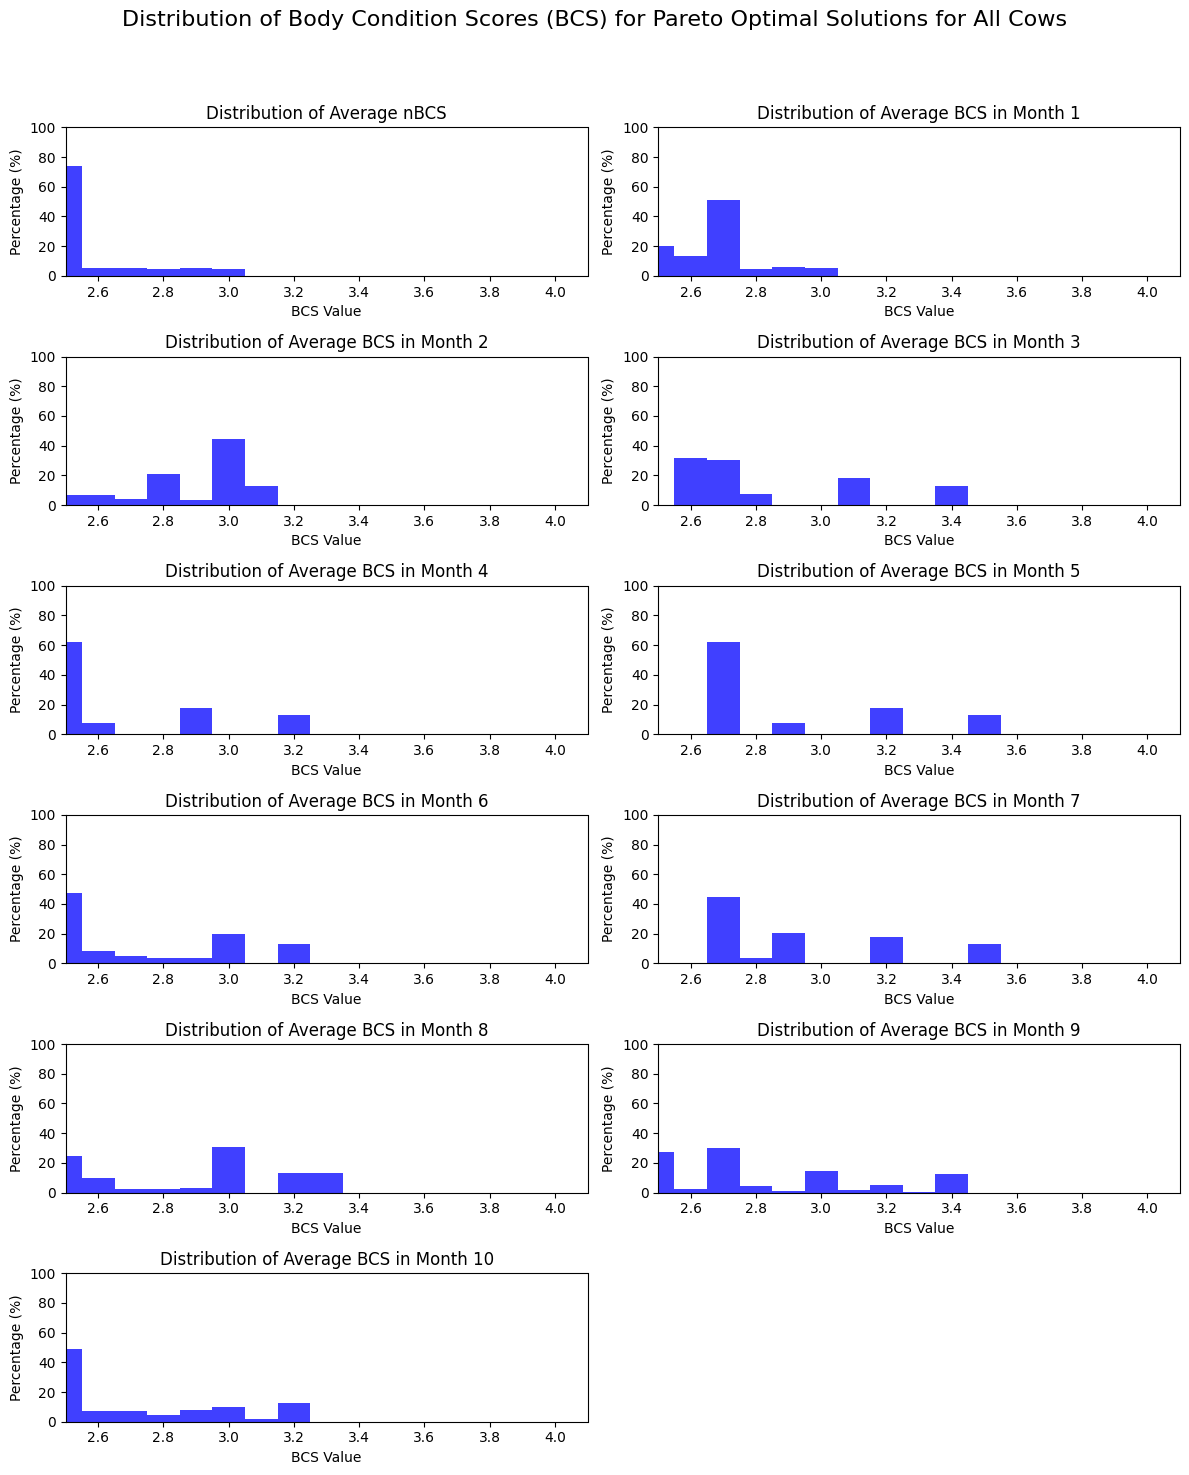

In [6]:
#All Cows #both
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            # (Though you've put these in a for-loop over i in range(9),
            #  notice you are not using 'i' here, so the same set of checks
            #  effectively runs 9 times. You can keep or remove that loop
            #  depending on your intent. Below is kept as-is.)
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.266:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.321:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.201:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.254:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.266:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.252:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.232:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.226:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            # Penalize any violation where x[0] > x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            # Your objective calculations
            milk_production = (20945 - 2314 * x[0] - 313 * x[1] + 1801 * x[2]
                               - 1369 * x[3] - 1896 * x[4] + 257 * x[5]
                               + 723 * x[6] - 1473 * x[7] + 978 * x[8]
                               + 880 * x[9] - 429 * x[10])

            conception_DIM = (189.07 - 29.73 * x[0] + 3.40 * x[1] + 23.22 * x[2]
                              - 32.00 * x[3] + 4.14 * x[4] - 29.52 * x[5]
                              + 51.78 * x[6] - 55.77 * x[7] + 23.72 * x[8]
                              + 18.42 * x[9] - 0.90 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6500)
plt.ylim(0, 700)

plt.title('e. Pareto Optimal Solutions for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for All Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage
    percentages = counts * np.diff(bins)[0] * 100

    # Plot the histogram using percentage on y-axis
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for All Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4457.85345188   201.92763503]
 [-5878.71880333   625.71256418]
 [-4897.50082958   234.57569888]
 ...
 [-5830.38433431   528.20062444]
 [-5145.46410075   257.82606259]
 [-5465.98456144   326.25195043]]

Final Decision Variables:
[[3.0405981  3.04063722 3.0408259  ... 3.04061632 3.10979282 3.34381051]
 [2.5        2.56514646 2.84714623 ... 2.75699488 2.99281409 2.75782526]
 [2.67220799 2.67225378 2.67255311 ... 2.67263608 2.67334608 2.90616745]
 ...
 [2.5        2.56515065 2.84713905 ... 2.75699058 2.99270265 2.76056918]
 [2.50000002 2.50000029 2.5006893  ... 2.50000385 2.50017435 2.73503771]
 [2.50000002 2.50000017 2.50189936 ... 2.5000567  2.50012251 2.73482476]]

Best Solution:
Objective Values: [-5780.69170275   473.00729164]
Decision Variables: [2.5        2.56514762 2.84714436 2.50128291 2.50000021 2.75288802
 2.50005654 2.50000055 2.75699664 2.99347642 3.22828582]

Worst Solution:
Objective Values: [-4457.85345188   201.92763503]
Decision Variables: [3.0

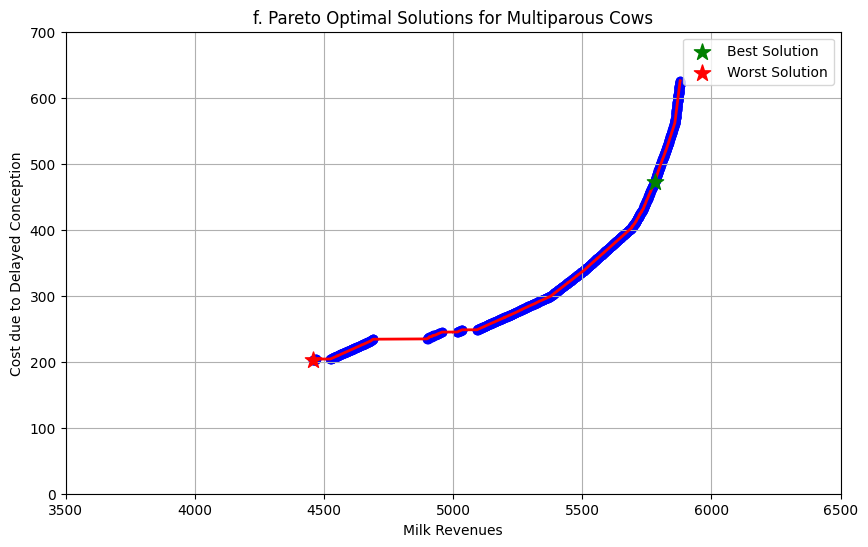

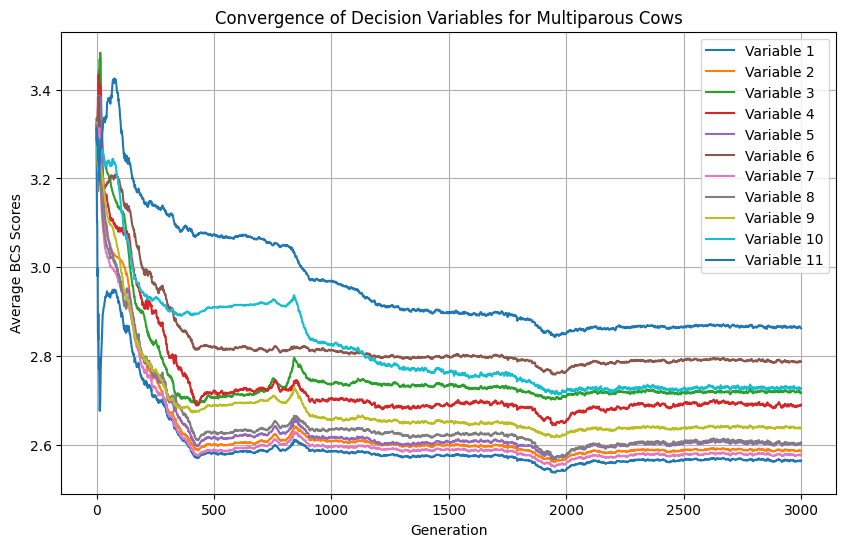

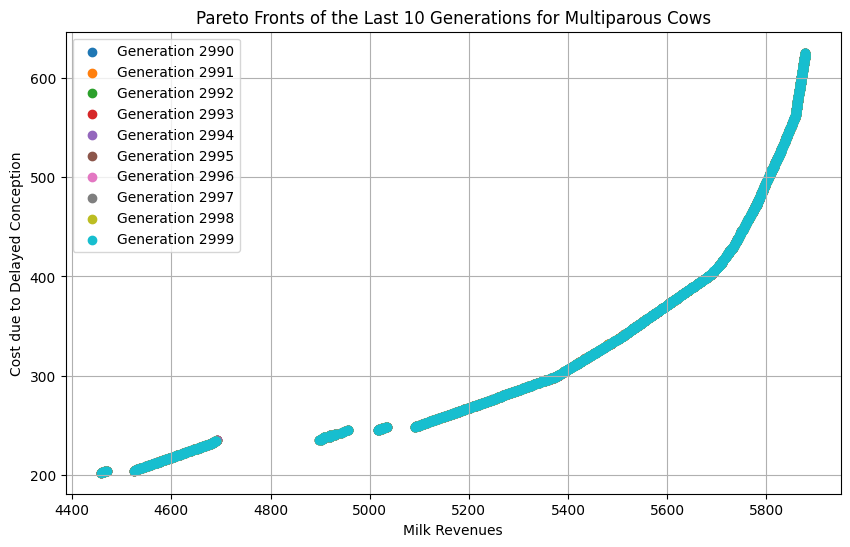

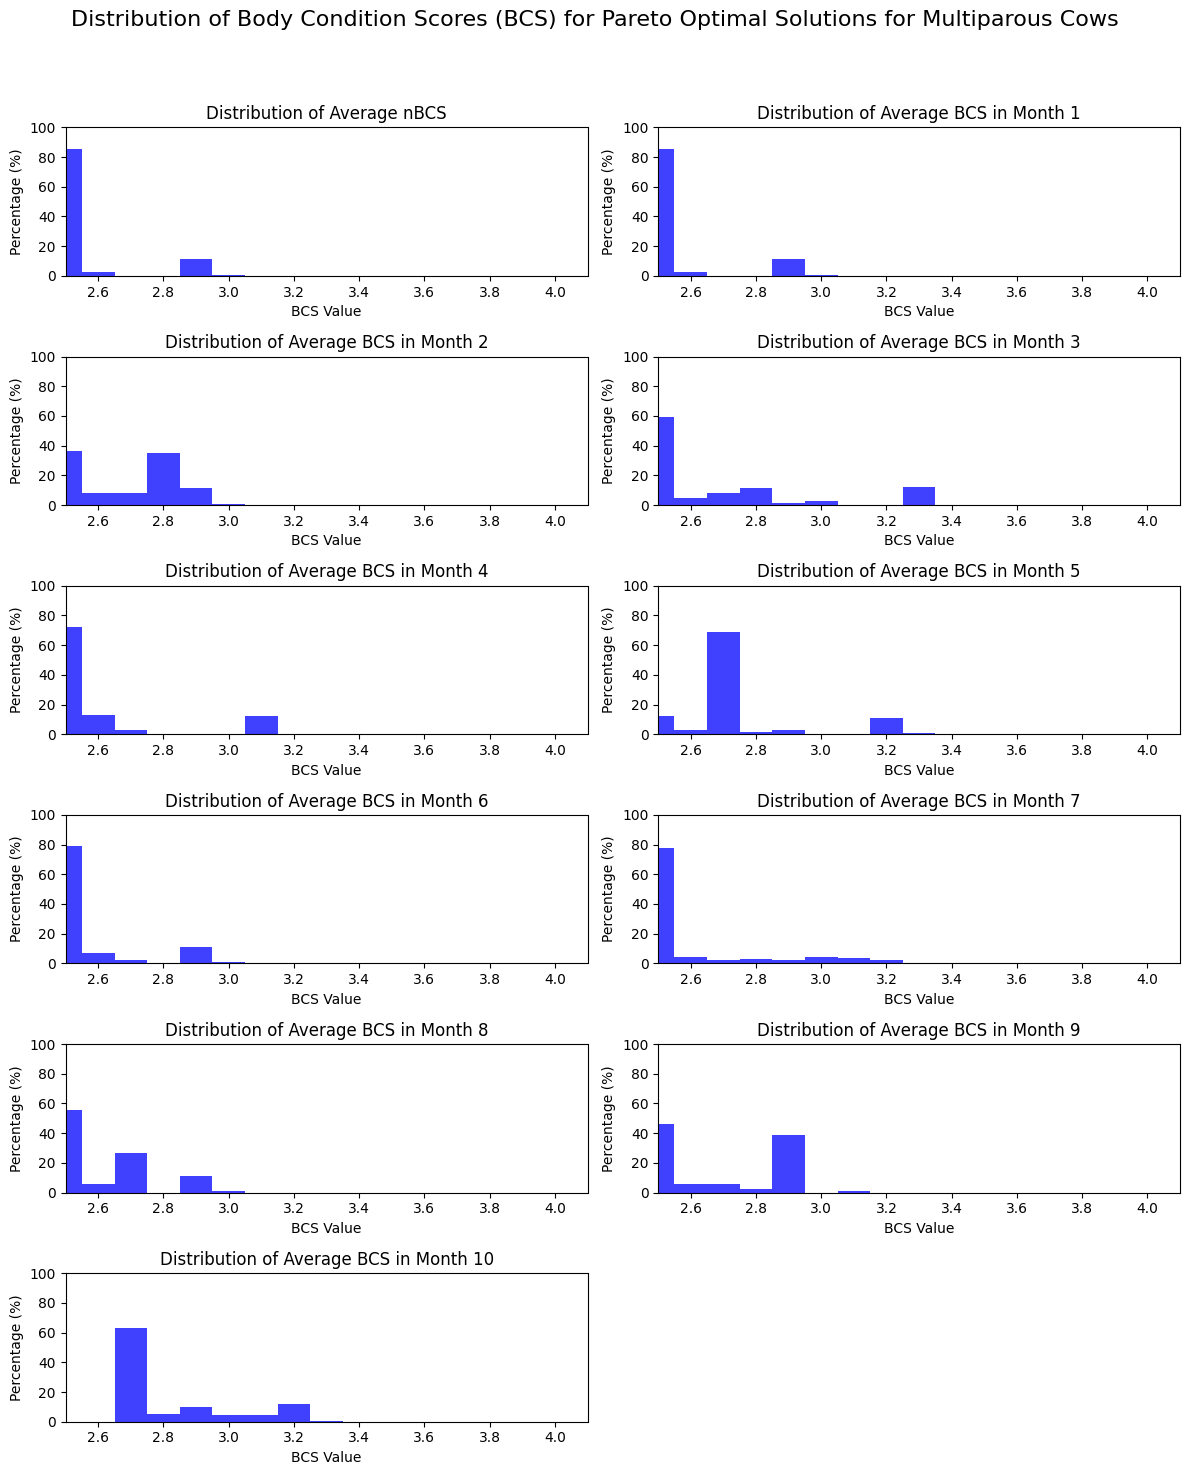

In [7]:
# Multiparous ##both
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.282:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.346:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.217:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.279:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.258:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.237:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.235:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (21323 - 410 * x[0] - 505 * x[1] + 1616 * x[2]
                               - 1535 * x[3] - 906 * x[4] - 311 * x[5]
                               + 195 * x[6] - 1532 * x[7] + 241 * x[8]
                               + 429 * x[9] - 247 * x[10])

            conception_DIM = (147.55 - 80.11 * x[0] + 15.83 * x[1] + 45.71 * x[2]
                              - 34.80 * x[3] + 1.63 * x[4] - 34.34 * x[5]
                              + 57.06 * x[6] - 20.09 * x[7] + 23.47 * x[8]
                              + 32.17 * x[9] - 23.97 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.04, 4.02, 5.34, 4.93, 4.37, 3.82, 3.23, 2.59, 1.94, 1.23]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worse_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worse_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(0, 700)
plt.title('f. Pareto Optimal Solutions for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Multiparous Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Multiparous Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()